# Task 6: House Price Prediction

### Objective:

Predict house prices using property features such as size, bedrooms, and location.

### Dataset:

House Price Prediction Dataset (available on Kaggle)

### Instructions:

● Perform preprocessing on features like square footage, number of bedrooms, and

location.

● Train a regression model (Linear Regression or Gradient Boosting).

● Visualize predicted prices compared to actual prices.

● Evaluate with Mean Absolute Error (MAE) and RMSE.

# Step : Required Libraries

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn.preprocessing import StandardScaler , MinMaxScaler

# Step:01 Load DataSet

In [97]:

df = pd.read_csv(r'C:\Users\Muhammad Yahya\Downloads\DevelopersHub-AI-Internship\DevelopersHub-AI-ML-Internship-Tasks\Task06_House_Price\usa_housing_kaggle.csv')
df.head(15) # Top 15Rows print

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4
5,744167,1,3.4,4330,1920,0,1.65,78011,4.37,9
6,210268,1,1.3,3435,1980,2,0.25,46378,11.08,4
7,832180,2,2.5,2370,1986,0,1.80,14255,59.85,2
8,154886,2,1.2,3360,2000,1,1.14,24484,9.50,5
9,237337,3,2.6,4191,2017,0,1.65,66549,37.60,3


In [98]:
df.tail(15) # Bottom 15Rows print

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
285,710490,3,1.2,2052,1979,3,1.46,52600,79.86,6
286,151663,1,2.0,971,1939,0,1.42,69560,96.78,2
287,115708,4,1.4,2258,1991,3,1.98,88040,85.69,4
288,978338,4,1.2,4349,1996,2,0.34,71558,11.76,3
289,411955,5,4.0,4997,1958,0,0.30,96205,73.97,7
290,233883,1,2.0,3122,1958,2,1.48,16910,31.97,9
291,418394,3,3.4,2436,1947,2,1.20,67713,98.84,5
292,212547,4,1.8,3915,1940,1,0.62,56857,48.54,6
293,659042,1,3.0,4890,1912,0,0.25,44964,12.24,2
294,851102,4,3.3,3804,2006,1,0.26,95667,72.52,3


# Step:02 Exploration DataSet

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Price         300 non-null    int64  
 1   Bedrooms      300 non-null    int64  
 2   Bathrooms     300 non-null    float64
 3   SquareFeet    300 non-null    int64  
 4   YearBuilt     300 non-null    int64  
 5   GarageSpaces  300 non-null    int64  
 6   LotSize       300 non-null    float64
 7   ZipCode       300 non-null    int64  
 8   CrimeRate     300 non-null    float64
 9   SchoolRating  300 non-null    int64  
dtypes: float64(3), int64(7)
memory usage: 23.6 KB


In [100]:
# This is most powerfull method
# provide Statistics Summary
df.describe()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
count,300.000000,300.000000,300.000000,300.00000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,522761.916667,2.966667,2.464000,3052.75000,1962.616667,1.513333,1.062200,54324.770000,49.324033,5.096667
std,256922.348275,1.451175,0.886184,1194.97144,36.005431,1.116832,0.543896,24718.938552,28.833220,2.674165
min,112666.000000,1.000000,1.000000,840.00000,1902.000000,0.000000,0.110000,10163.000000,0.190000,1.000000
25%,299936.500000,2.000000,1.700000,2053.50000,1931.750000,1.000000,0.570000,34175.000000,22.547500,3.000000
50%,505806.500000,3.000000,2.400000,3127.00000,1961.000000,1.000000,1.085000,54896.500000,49.970000,5.000000
75%,744603.750000,4.000000,3.200000,4081.00000,1994.000000,3.000000,1.482500,74108.000000,74.402500,8.000000
max,999684.000000,5.000000,4.000000,4997.00000,2022.000000,3.000000,2.000000,99881.000000,99.710000,9.000000


In [101]:
# Rows , Columns
df.shape

(300, 10)

# Step:03 Preprocessing

#### Scalling

In [102]:
df[['SquareFeet','LotSize']] = StandardScaler().fit_transform(df[['SquareFeet','LotSize']])
df

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,1.487244,1979,2,0.714196,82240,48.60,5
1,771155,2,2.0,-1.691355,1987,2,1.266694,74315,92.03,9
2,231932,1,3.0,-0.237850,1982,1,0.732612,79249,52.08,3
3,465838,3,3.3,-0.288983,1907,3,1.027278,80587,61.65,1
4,359178,4,3.4,-1.574002,1994,2,-0.593383,20756,15.66,4
...,...,...,...,...,...,...,...,...,...,...
295,862002,4,2.8,-1.612561,1944,0,1.358777,35227,32.30,3
296,242483,3,2.4,1.162846,1988,2,-1.109047,15978,99.71,9
297,758271,2,2.2,1.375759,1952,2,-0.648633,97527,97.98,7
298,314835,5,2.0,1.554303,1941,3,-0.980131,27153,65.61,8


#### Target Encode

In [103]:
zip_map = df.groupby('ZipCode')['Price'].mean().to_dict()
df['Location_Score'] = df['ZipCode'].map(zip_map)

#### Detect Outliers Using z_score 

In [104]:
# Calculate z_score for df
z_score = np.abs(zscore(df))

# z_score > 3 = outliers
outliers = (z_score > 3).any(axis=1)
outliers

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,

# Step:04 Create Two Variables
1.Dependent 

2.Independent

In [105]:
X = df[['Bedrooms','Bathrooms','SquareFeet','YearBuilt','GarageSpaces','LotSize','Location_Score','CrimeRate','SchoolRating']] #independent Features
y = df['Price'] #Depenedent/Target

In [106]:
X.head()

,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,Location_Score,CrimeRate,SchoolRating
0,1,1.9,1.487244,1979,2,0.714196,221958.0,48.60,5
1,2,2.0,-1.691355,1987,2,1.266694,771155.0,92.03,9
2,1,3.0,-0.237850,1982,1,0.732612,231932.0,52.08,3
3,3,3.3,-0.288983,1907,3,1.027278,465838.0,61.65,1
4,4,3.4,-1.574002,1994,2,-0.593383,359178.0,15.66,4


In [107]:
y.head()

0    221958
1    771155
2    231932
3    465838
4    359178
Name: Price, dtype: int64

# Step:05 Split Data

In [108]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Step:06 Select Model And Training

In [109]:
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5
)
model = model.fit(X_train , y_train)
model

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

#### Intercept

In [110]:
intercept = model.intercept_
intercept

array([508574.06], dtype=float32)

# Step:07 Prediction

In [111]:
y_predicted = model.predict(X_test)
y_predicted

array([635707.6 , 573268.25, 981631.06, 237130.88, 542648.06, 635690.5 ,
       206968.02, 817336.75, 736969.44, 729566.44, 289321.2 , 449014.12,
       501890.8 , 175453.2 , 825709.4 , 114895.55, 402900.47, 784998.6 ,
       588784.8 , 218518.47, 559523.94, 335476.94, 911654.56, 320593.1 ,
       561030.7 , 551223.3 , 961993.75, 850714.7 , 561036.75, 314687.38,
       428938.94, 736934.5 , 582533.56, 300209.6 , 715191.5 , 362784.94,
       829560.75, 290383.56, 691506.94, 894447.4 , 722662.9 , 701504.1 ,
       149483.69, 339950.8 , 921334.2 , 794417.56, 937635.56, 979686.06,
       531628.6 , 691629.06, 829460.94, 449084.5 , 403072.5 , 205957.61,
       753449.3 , 710516.5 , 884172.44, 320336.2 , 141289.47, 894089.75],
      dtype=float32)

# Step:08 Model Evaluation 
#### Use Regression Metrics

In [112]:
print(f'MAE={mean_absolute_error(y_test,y_predicted)}')
print(f'MSE={mean_squared_error(y_test , y_predicted)}')
print(f'RMSE={np.sqrt(mean_squared_error(y_test,y_predicted))}')
print(f'R_score={r2_score(y_test , y_predicted)}')

MAE=3552.598388671875
MSE=24177966.0
RMSE=4917.109516779141
R_score=0.9996136426925659


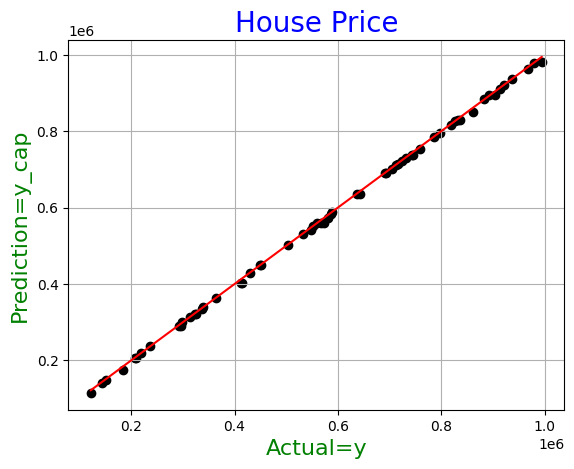

In [113]:
plt.scatter(y_test , y_predicted , color='black')
plt.xlabel('Actual=y' , fontsize=16 , color='g')
plt.ylabel('Prediction=y_cap' ,  fontsize=16 , color='g')
plt.title('House Price' , fontsize=20 , color='blue')

# X-coordinates: [y_test.min(), y_test.max()] , Y-coordinates: [y_test.min(), y_test.max()]
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , color='r')
plt.grid()
plt.show()